# Setup


In [2]:

import pandas as pd

In [3]:
import sys
sys.path.append(r"/")

from provenance_coo import Provenance

# TCP-DI

In [4]:
import os

def load_data(scale):
    directory = f"../data/TPC-DI/Join/scale_{scale}"
    history_path = os.path.join(directory, "HoldingHistory.csv")
    trade_path = os.path.join(directory, "Trade.csv")
    history_df = pd.read_csv(history_path)
    trade_df = pd.read_csv(trade_path)
    return history_df, trade_df

# history_df, trade_df = load_data(scale=3)
# display(history_df.head())
# display(trade_df.head())

# joined_df = pd.merge(history_df, trade_df, left_on="HH_T_ID", right_on="T_ID", how="inner")
# display(joined_df.head())


In [6]:
runtimes = []
scales = [3, 5, 9, 15, 20]

for scale in scales:
    print(f"\n-- Scale: {scale} --\n")
    prov = Provenance(save_dir=f"TCPDI_results/scale_{scale}", verbose=0)
    history_df, trade_df = load_data(scale=scale)
    # history_wdf = prov.subscribe(history_df)
    # trade_wdf = prov.subscribe(trade_df)    
    # joined_wdf = history_wdf.merge(trade_wdf, left_on="HH_H_T_ID", right_on="T_ID", how="inner")
    # runtimes.append(prov.last_runtime)
    # print("joined_wdf.shape: ", joined_wdf.shape)
    print(history_df.shape, trade_df.shape)


-- Scale: 3 --

(362342, 4) (390978, 14)

-- Scale: 5 --

(602956, 4) (650412, 14)

-- Scale: 9 --

(1085239, 4) (1171107, 14)

-- Scale: 15 --

(1807703, 4) (1951236, 14)

-- Scale: 20 --

(2411006, 4) (2601648, 14)


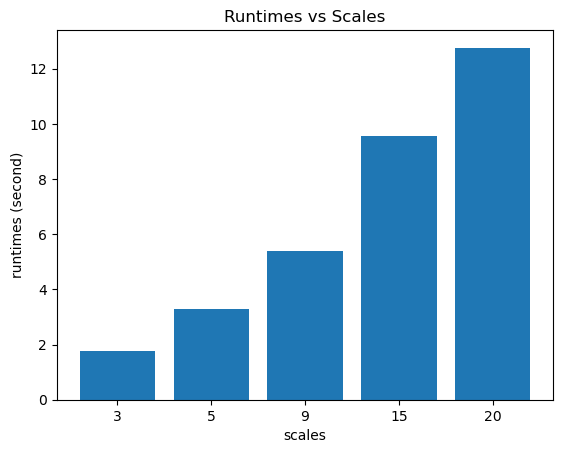

In [9]:
import matplotlib.pyplot as plt

plt.bar([str(s) for s in scales], runtimes)
plt.xlabel('scales')
plt.ylabel('runtimes (second)')
plt.title('Runtimes vs Scales')
plt.show()

In [11]:
from pathlib import Path

def get_dir_size(path: Path) -> int:
    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file())

base = Path("TCPDI_results")
sizes = []

for scale in scales:
    folder = base / f"scale_{scale}"
    print(f"\n-- Scale: {scale} --\n")
    if folder.exists() and folder.is_dir():
        size_bytes = get_dir_size(folder)
        size_mb = size_bytes / (1024**2)
        sizes.append(size_mb)
        print(f"{folder.name}: {size_mb:.2f} MB")
    else:
        print(f"{folder.name} not exists")



-- Scale: 3 --

scale_3: 3.20 MB

-- Scale: 5 --

scale_5: 3.61 MB

-- Scale: 9 --

scale_9: 6.50 MB

-- Scale: 15 --

scale_15: 10.90 MB

-- Scale: 20 --

scale_20: 14.58 MB


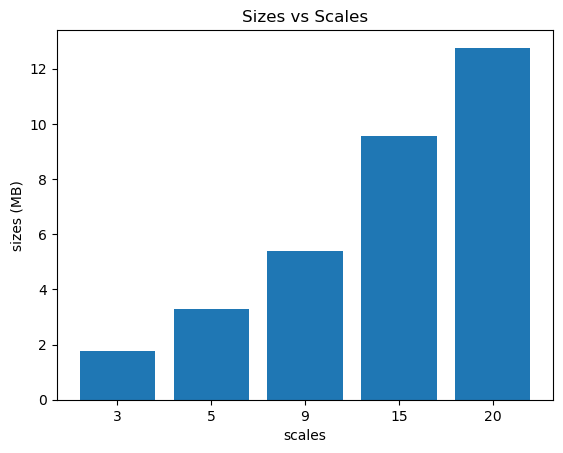

In [12]:
import matplotlib.pyplot as plt

plt.bar([str(s) for s in scales], runtimes)
plt.xlabel('scales')
plt.ylabel('sizes (MB)')
plt.title('Sizes vs Scales')
plt.show()

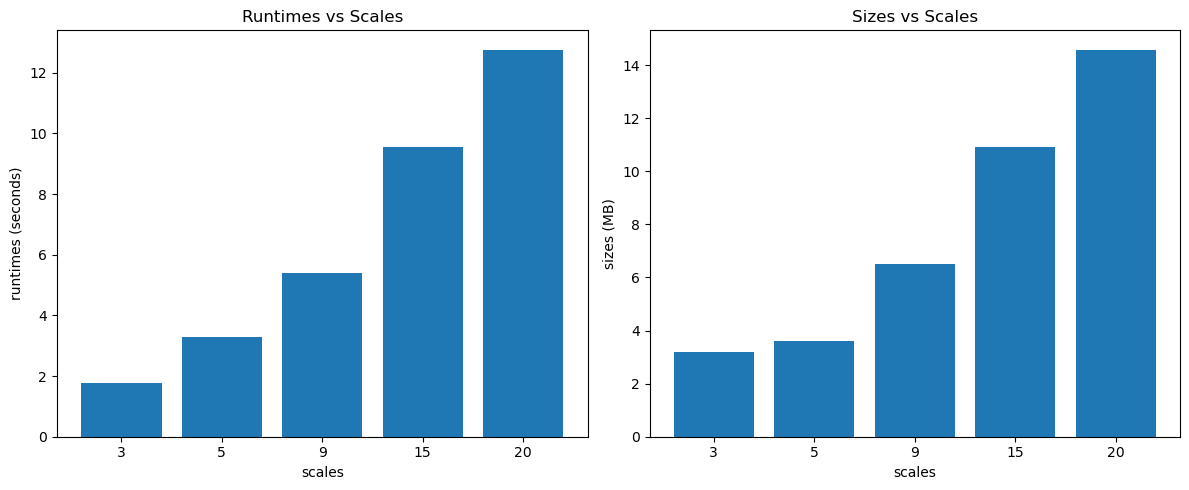

In [14]:
import matplotlib.pyplot as plt

scales   = [3, 5, 9, 15, 20]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar([str(s) for s in scales], runtimes)
axes[0].set_xlabel("scales")
axes[0].set_ylabel("runtimes (seconds)")
axes[0].set_title("Runtimes vs Scales")

axes[1].bar([str(s) for s in scales], sizes)
axes[1].set_xlabel("scales")
axes[1].set_ylabel("sizes (MB)")
axes[1].set_title("Sizes vs Scales")

plt.tight_layout()
plt.show()


In [15]:
print(sizes)

[3.200444221496582, 3.6095504760742188, 6.495573997497559, 10.897696495056152, 14.578717231750488]


In [16]:
print(runtimes)

[1.7818794250488281, 3.278573989868164, 5.400340557098389, 9.560372352600098, 12.759066104888916]


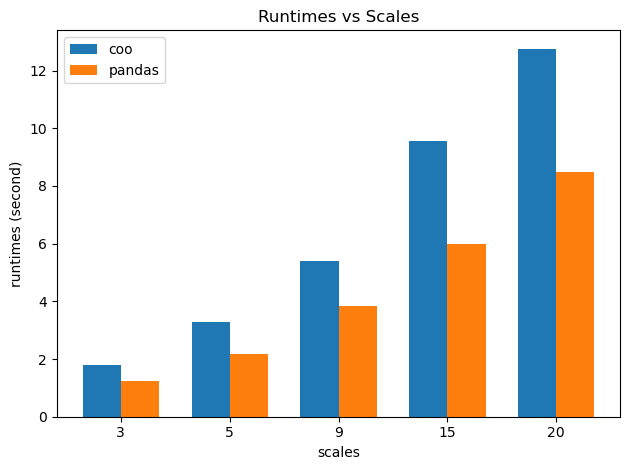

In [22]:

import numpy as np
import matplotlib.pyplot as plt


scales = [3, 5, 9, 15, 20]
runtimes_coo = [1.7818794250488281, 3.278573989868164, 5.400340557098389, 9.560372352600098, 12.759066104888916]
runtimes_pandas = [1.224066972732544, 2.177572011947632, 3.8252034187316895, 5.982793807983398, 8.497344255447388]

x = np.arange(len(scales))
width = 0.35

plt.figure()
plt.bar(x - width/2, runtimes_coo, width=width, label='coo', color='tab:blue')
plt.bar(x + width/2, runtimes_pandas, width=width, label='pandas', color='tab:orange')

plt.xticks(x, [str(s) for s in scales])
plt.xlabel('scales')
plt.ylabel('runtimes (second)')
plt.title('Runtimes vs Scales')
plt.legend()
plt.tight_layout()
plt.show()


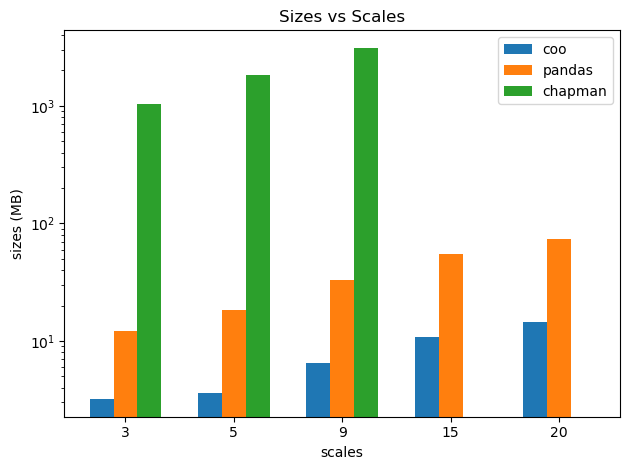

In [23]:
import numpy as np
import matplotlib.pyplot as plt

scales = [3, 5, 9, 15, 20]
sizes_coo = [3.200444221496582, 3.6095504760742188, 6.495573997497559, 10.897696495056152, 14.578717231750488]
sizes_pandas = [12.093904495239258, 18.403196334838867, 33.12130546569824, 55.16915702819824, 73.58050346374512]
sizes_chapman = [1.02, 1.78, 3.04, 0, 0]
sizes_chapman = [x * 1024 for x in sizes_chapman]

x = np.arange(len(scales))
width = 0.22

plt.figure()
plt.bar(x - width,          sizes_coo,     width=width, label='coo',     color='tab:blue')
plt.bar(x,                  sizes_pandas,  width=width, label='pandas',  color='tab:orange')
plt.bar(x + width,          sizes_chapman, width=width, label='chapman', color='tab:green')

plt.xticks(x, [str(s) for s in scales])
plt.xlabel('scales')
plt.ylabel('sizes (MB)')
plt.title('Sizes vs Scales')
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()
